In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("Week 7 Skill: Random Forests")

Week 7 Skill: Random Forests


In [102]:
df = pd.read_csv('/content/placement_predict_50k.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50000, 31)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
0,1,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.39,6.84,...,1,0,62.3,6.57,40.6,65.7,No,Medium,0,0
1,2,Male,Chennai,Tier2,ECE,AI,Yes,No,5.95,6.74,...,2,0,44.0,5.86,40.3,51.8,No,Medium,0,0
2,3,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.13,8.11,...,2,1,73.8,7.50,73.6,67.9,No,High,1,0
3,4,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.37,9.97,...,6,2,100.0,9.41,98.7,NaN,No,Excellent,1,0
4,5,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,8.25,8.99,...,4,2,90.8,9.24,83.1,100.0,No,Excellent,1,0


In [103]:
df = df.drop(columns=['IsAnomaly'], errors='ignore')

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values:", df.isnull().sum().sum())

Missing values: 0


In [104]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (50000, 45)
Target: (50000,)


In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 45)
Testing data: (10000, 45)


In [106]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("OOB Accuracy:", rf.oob_score_)

Random Forest Accuracy: 0.7909
OOB Accuracy: 0.788675


In [107]:
n_estimators_list = [10, 25, 50, 100]
oob_errors = []

for n in n_estimators_list:
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        oob_score=True,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    oob_errors.append(1 - model.oob_score_)

print("OOB Errors:", oob_errors)

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


OOB Errors: [0.25585, 0.224225, 0.216275, 0.21132499999999999]


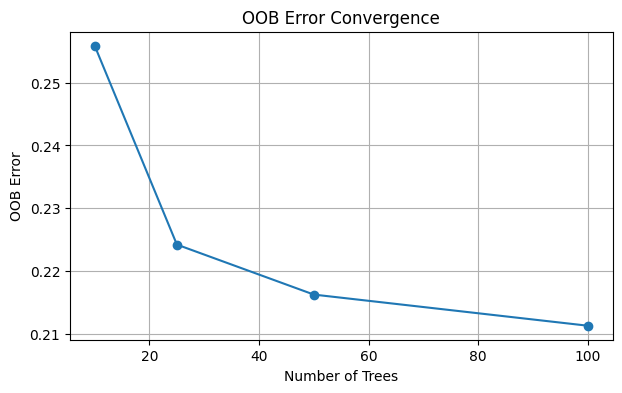

In [108]:
plt.figure(figsize=(7, 4))

plt.plot(n_estimators_list, oob_errors, marker='o')

plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("OOB Error Convergence")
plt.grid(True)

plt.show()

In [109]:
max_features_values = ['sqrt', 'log2', None]
feature_results = []

for value in max_features_values:
    model = RandomForestClassifier(
        n_estimators=20,
        max_features=value,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    feature_results.append({
        'max_features': str(value),
        'Accuracy': accuracy_score(y_test, pred)
    })

feature_results = pd.DataFrame(feature_results)

print(feature_results)

  max_features  Accuracy
0         sqrt    0.7888
1         log2    0.7894
2         None    0.7887


In [110]:
bagged_models = []

for i in range(10):
    sample_indices = np.random.choice(
        len(X_train),
        size=len(X_train),
        replace=True
    )

    X_sample = X_train.iloc[sample_indices]
    y_sample = y_train.iloc[sample_indices]

    tree = DecisionTreeClassifier(
        max_depth=5,
        random_state=i
    )

    tree.fit(X_sample, y_sample)
    bagged_models.append(tree)

predictions = np.array([
    tree.predict(X_test)
    for tree in bagged_models
])

bagged_pred = np.apply_along_axis(
    lambda x: np.bincount(x).argmax(),
    axis=0,
    arr=predictions
)

print("Manual Bagging Accuracy:",
      accuracy_score(y_test, bagged_pred))

Manual Bagging Accuracy: 0.7905


In [111]:
tree = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)
rf_pred = rf.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, tree_pred))

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Decision Tree Accuracy: 0.7753
Random Forest Accuracy: 0.7909


In [112]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 Important Features:")
print(importance.head(10))

Top 10 Important Features:
CGPA                 0.127466
SGPA_Sem8            0.081332
SGPA_Sem3            0.063735
SGPA_Sem7            0.058418
SGPA_Sem2            0.056562
SGPA_Sem5            0.056071
SGPA_Sem4            0.054576
SGPA_Sem1            0.053381
AptitudeTestScore    0.050237
SGPA_Sem6            0.049864
dtype: float64
